<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/IOE_EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=========== EDGE DEVICE ===========
Current Soil Moisture : 9 %
Stored at Edge : 50

=========== CLOUD ===========
Cloud Records : 50
Mean : 53.92
Moving Average : 15.0
Standard Deviation : 17.56
Status : DRY SOIL - IRRIGATION NEEDED


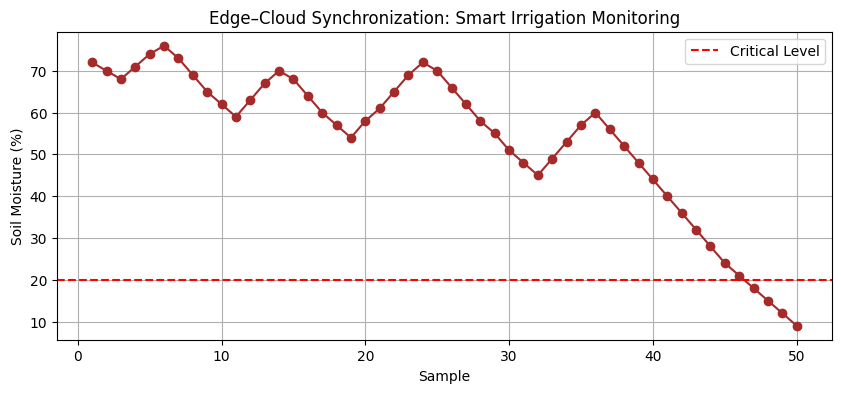

Experiment Completed Successfully


In [1]:

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

edge_storage = []
cloud_storage = []
time_data = []

# Realistic varying soil moisture dataset (50 samples, % moisture)
soil_moisture = [
    72, 70, 68, 71, 74, 76, 73, 69, 65, 62,
    59, 63, 67, 70, 68, 64, 60, 57, 54, 58,
    61, 65, 69, 72, 70, 66, 62, 58, 55, 51,
    48, 45, 49, 53, 57, 60, 56, 52, 48, 44,
    40, 36, 32, 28, 24, 21, 18, 15, 12, 9
]

for i in range(1, 51):
    moisture_level = soil_moisture[i - 1]

    # Edge Storage
    edge_storage.append(moisture_level)

    # Synchronize to Cloud
    cloud_storage.append(moisture_level)

    time_data.append(i)

    mean = np.mean(cloud_storage)
    std = np.std(cloud_storage)

    if len(cloud_storage) >= 5:
        moving = np.mean(cloud_storage[-5:])
    else:
        moving = mean

    if moisture_level < 20:
        status = "DRY SOIL - IRRIGATION NEEDED"
    else:
        status = "NORMAL"

    clear_output(wait=True)

    print("=========== EDGE DEVICE ===========")
    print("Current Soil Moisture :", moisture_level, "%")
    print("Stored at Edge :", len(edge_storage))
    print()

    print("=========== CLOUD ===========")
    print("Cloud Records :", len(cloud_storage))
    print("Mean :", round(mean, 2))
    print("Moving Average :", round(moving, 2))
    print("Standard Deviation :", round(std, 2))
    print("Status :", status)

    plt.figure(figsize=(10, 4))
    plt.plot(time_data, cloud_storage, marker='o', color='brown')
    plt.axhline(20, color='red', linestyle='--', label='Critical Level')
    plt.xlabel("Sample")
    plt.ylabel("Soil Moisture (%)")
    plt.title("Edge–Cloud Synchronization: Smart Irrigation Monitoring")
    plt.legend()
    plt.grid(True)
    plt.show()

    time.sleep(0.5)

df = pd.DataFrame({
    "Sample": time_data,
    "Soil Moisture": cloud_storage
})

df.to_csv("cloud_soil_data.csv", index=False)

print("Experiment Completed Successfully")